# Chapter 86 - Inspecting Attention Patterns

Causal self-attention assigns weights to allowed source positions for every token position.

This chapter exposes those weights, verifies their structure, and visualizes differences across layers and heads without treating them as a complete explanation of the model.

## Learning goals

By the end of this chapter, you will be able to:

- modify attention modules to optionally return pre-dropout attention weights;

- propagate weights through multi-head attention, Transformer blocks, and the full model;

- verify attention tensor shapes, row sums, and causal masking;

- plot token-labeled heatmaps across heads and layers;

- compare final-position attention distributions and next-token predictions; and

- describe what attention inspection can and cannot establish.

## Terms and limits

An **attention weight** is one entry in the probability distribution produced by a head for one query position.

An **attention matrix** contains those distributions for every query position in one sequence.

A **head** is one independently parameterized attention calculation inside a Transformer block.

A **layer** in this notebook means one Transformer block.

A **heatmap** maps matrix values to colors so spatial patterns are easier to compare.

An **attention pattern** shows information routing through one sublayer, not the complete computation that caused a prediction.

Value vectors, output projections, residual connections, feedforward networks, layer normalization, and later layers all affect the final logits.

> A high attention weight is evidence that a head routed information from a position for this prompt.
>
> It is not, by itself, proof that the position caused the model's prediction.

## Read an attention matrix

The tensor layout used here is `[batch, head, query position, key position]`.

- A row is the query position doing the attending.

- A column is the key position being attended to.

- Each pre-dropout row sums to approximately `1` because it comes from a softmax.

- Cells above the main diagonal are `0` because a causal model cannot use future positions.

The phrase “query attends to key” describes the row-to-column direction.

## See masking before training

A three-position toy example isolates the causal mask from the learned model.

The score values are arbitrary and exist only to show how masking changes softmax probabilities.

In [1]:
import torch  # noqa: I001


toy_scores = torch.tensor(
    [
        [1.0, 2.0, 3.0],
        [2.0, 1.0, 3.0],
        [1.0, 3.0, 2.0],
    ]
)
toy_causal_mask = torch.tril(torch.ones(3, 3, dtype=torch.bool))
toy_masked_scores = toy_scores.masked_fill(~toy_causal_mask, float("-inf"))
toy_attention_weights = torch.softmax(toy_masked_scores, dim=-1)

print("Causal mask:")
print(toy_causal_mask)
print("\nAttention weights:")
print(toy_attention_weights)
print("\nRow sums:", toy_attention_weights.sum(dim=-1))

assert torch.equal(
    torch.triu(toy_attention_weights, diagonal=1),
    torch.zeros_like(toy_attention_weights),
)
assert torch.allclose(toy_attention_weights.sum(dim=-1), torch.ones(3))

Causal mask:
tensor([[ True, False, False],
        [ True,  True, False],
        [ True,  True,  True]])

Attention weights:
tensor([[1.0000, 0.0000, 0.0000],
        [0.7311, 0.2689, 0.0000],
        [0.0900, 0.6652, 0.2447]])

Row sums: tensor([1.0000, 1.0000, 1.0000])


The first query can use only the first key, while the final query can distribute weight across all three keys.

Training changes the unmasked scores, but causal masking preserves this lower-triangular constraint.

## Build a leakage-free character dataset

Three public-domain excerpts form training data and a different excerpt forms validation data.

Holding out a separate passage avoids placing duplicated text on both sides of a positional split.

Character tokens keep the tokenizer transparent, although repeated characters require position-aware plot labels.

In [2]:
training_documents = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a daisy
chain would be worth the trouble of getting up and picking the daisies, when
suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
be too late! But when the rabbit actually took a watch out of its waistcoat
pocket, and looked at it, and then hurried on, Alice started to her feet.""",
]
validation_text = """The rabbit hole went straight on like a tunnel for some way,
and then dipped suddenly down, so suddenly that Alice had not a moment to think
about stopping herself before she found herself falling down what seemed to be
a very deep well."""
training_text = "\n\n".join(training_documents)
characters = sorted(set(training_text))
character_to_id = {character: index for index, character in enumerate(characters)}
id_to_character = {index: character for character, index in character_to_id.items()}


def encode_text(text: str) -> list[int]:
    unknown_characters = sorted(set(text) - set(character_to_id))
    if unknown_characters:
        raise ValueError(f"Unknown characters: {unknown_characters!r}.")
    return [character_to_id[character] for character in text]


def decode_to_tokens(token_ids: list[int]) -> list[str]:
    return [id_to_character[token_id] for token_id in token_ids]


training_token_ids = torch.tensor(encode_text(training_text), dtype=torch.long)
validation_token_ids = torch.tensor(encode_text(validation_text), dtype=torch.long)
vocabulary_size = len(characters)

print("Vocabulary size:", vocabulary_size)
print("Training tokens:", training_token_ids.numel())
print("Validation tokens:", validation_token_ids.numel())

Vocabulary size: 35
Training tokens: 896
Validation tokens: 237


## Build reproducible GPT batches

An explicit generator makes the sampled windows reproducible without relying on hidden global random state.

In [3]:
def get_gpt_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    valid_starts = token_ids.numel() - context_length
    if token_ids.ndim != 1 or valid_starts < 1:
        raise ValueError(
            "Token stream must be one-dimensional and longer than context_length."
        )
    starts = torch.randint(0, valid_starts, (batch_size,), generator=generator)
    offsets = torch.arange(context_length)
    indexes = starts[:, None] + offsets[None, :]
    return token_ids[indexes], token_ids[indexes + 1]


test_generator = torch.Generator().manual_seed(86)
test_inputs, test_targets = get_gpt_training_batch(
    training_token_ids, 4, 16, test_generator
)
print("Input shape:", tuple(test_inputs.shape))
print("Target shift correct:", torch.equal(test_targets[:, :-1], test_inputs[:, 1:]))
assert torch.equal(test_targets[:, :-1], test_inputs[:, 1:])

Input shape: (4, 16)
Target shift correct: True


## Return weights from multi-head attention

The implementation computes all heads in one tensor and optionally returns the softmax weights before attention dropout.

Pre-dropout rows retain their probability-distribution interpretation.

The value path still uses dropped weights during training, so requesting inspection does not change the model computation.

In [4]:
import math  # noqa: I001


class InspectableMultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        if not 0.0 <= dropout_rate < 1.0:
            raise ValueError("dropout_rate must be in [0, 1).")

        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(
        self,
        input_values: torch.Tensor,
        return_attention_weights: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(
            ~causal_mask,
            float("-inf"),
        )
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attended_values = self.attention_dropout(attention_weights) @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(batch_size, sequence_length, self.embedding_dimension)
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        if return_attention_weights:
            return output_values, attention_weights
        return output_values, None

For one layer, returned weights have shape `[batch, head, query, key]`.

Stacking separate single-head outputs is also valid, but the vectorized layout makes the dimensions explicit and avoids a Python loop over heads.

## Pass weights through each Transformer block

The feedforward network has no attention weights.

Each block returns its normal residual-stream output plus the optional weights from its attention sublayer.

In [5]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class InspectableTransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = InspectableMultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForwardNetwork(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(
        self,
        input_values: torch.Tensor,
        return_attention_weights: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        attention_branch, attention_weights = self.attention(
            self.attention_norm(input_values),
            return_attention_weights=return_attention_weights,
        )
        values_after_attention = input_values + attention_branch
        feedforward_branch = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_branch
        return output_values, attention_weights

## Collect weights from the full model

The model returns one attention tensor per block only when requested.

Normal training passes `False`, avoiding the list of retained intermediate references.

In [6]:
class InspectableTinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        self.position_embedding = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.ModuleList(
            [
                InspectableTransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
        return_attention_weights: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor | None, list[torch.Tensor] | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("Inputs must have shape [batch, time].")
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")

        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        collected_attention_weights: list[torch.Tensor] = []
        for transformer_block in self.transformer_blocks:
            hidden_values, attention_weights = transformer_block(
                hidden_values,
                return_attention_weights=return_attention_weights,
            )
            if return_attention_weights:
                if attention_weights is None:
                    raise RuntimeError("Requested attention weights were not returned.")
                collected_attention_weights.append(attention_weights)

        logits = self.output_layer(self.final_norm(hidden_values))
        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        returned_weights = (
            collected_attention_weights if return_attention_weights else None
        )
        return logits, loss, returned_weights

## Configure a small training run

The architecture matches recent chapters and performs exactly 800 optimizer updates.

Attention extraction is disabled during training because loss computation does not need the returned list.

In [7]:
from typing import TypedDict


class AttentionConfig(TypedDict):
    context_length: int
    embedding_dimension: int
    number_of_attention_heads: int
    number_of_transformer_blocks: int
    dropout_rate: float
    batch_size: int
    learning_rate: float
    weight_decay: float
    training_steps: int
    evaluation_interval: int
    evaluation_batches: int


attention_config: AttentionConfig = {
    "context_length": 64,
    "embedding_dimension": 64,
    "number_of_attention_heads": 4,
    "number_of_transformer_blocks": 2,
    "dropout_rate": 0.1,
    "batch_size": 8,
    "learning_rate": 0.0003,
    "weight_decay": 0.01,
    "training_steps": 800,
    "evaluation_interval": 100,
    "evaluation_batches": 8,
}
print(attention_config)

{'context_length': 64, 'embedding_dimension': 64, 'number_of_attention_heads': 4, 'number_of_transformer_blocks': 2, 'dropout_rate': 0.1, 'batch_size': 8, 'learning_rate': 0.0003, 'weight_decay': 0.01, 'training_steps': 800, 'evaluation_interval': 100, 'evaluation_batches': 8}


## Evaluate fixed batches with dropout off

Every checkpoint reuses the same sampled windows so changes reflect the model rather than evaluation-batch noise.

The helper restores the model's previous mode after evaluation.

In [8]:
@torch.no_grad()
def estimate_losses(
    model: InspectableTinyGPT,
    config: AttentionConfig,
    seed: int,
) -> dict[str, float]:
    was_training = model.training
    model.eval()
    results: dict[str, float] = {}
    for offset, (name, token_ids) in enumerate(
        [("train", training_token_ids), ("validation", validation_token_ids)]
    ):
        generator = torch.Generator().manual_seed(seed + offset)
        losses: list[float] = []
        for _ in range(config["evaluation_batches"]):
            inputs, targets = get_gpt_training_batch(
                token_ids,
                config["batch_size"],
                config["context_length"],
                generator,
            )
            _, loss, _ = model(inputs, targets)
            if loss is None or not torch.isfinite(loss):
                raise RuntimeError("Evaluation loss is non-finite.")
            losses.append(float(loss.item()))
        results[name] = sum(losses) / len(losses)
    model.train(was_training)
    return results

## Train the inspectable model

The loop retains checkpoint losses but not attention tensors.

Gradient clipping continues the stable training pattern from Chapter 85 rather than creating a new clipping comparison.

In [9]:
from dataclasses import dataclass


@dataclass
class TrainingResult:
    model: InspectableTinyGPT
    evaluation_steps: list[int]
    training_losses: list[float]
    validation_losses: list[float]
    optimizer_updates: int


def train_inspectable_model(config: AttentionConfig) -> TrainingResult:
    torch.manual_seed(8601)
    model = InspectableTinyGPT(
        vocabulary_size=vocabulary_size,
        context_length=config["context_length"],
        embedding_dimension=config["embedding_dimension"],
        number_of_attention_heads=config["number_of_attention_heads"],
        number_of_transformer_blocks=config["number_of_transformer_blocks"],
        dropout_rate=config["dropout_rate"],
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    batch_generator = torch.Generator().manual_seed(8602)
    evaluation_steps: list[int] = []
    training_losses: list[float] = []
    validation_losses: list[float] = []

    def checkpoint(step: int) -> None:
        losses = estimate_losses(model, config, seed=8603)
        evaluation_steps.append(step)
        training_losses.append(losses["train"])
        validation_losses.append(losses["validation"])
        print(
            f"step {step:>3} | train {losses['train']:.4f} | "
            f"validation {losses['validation']:.4f}"
        )

    torch.manual_seed(8602)
    model.train()
    checkpoint(0)
    for step in range(1, config["training_steps"] + 1):
        inputs, targets = get_gpt_training_batch(
            training_token_ids,
            config["batch_size"],
            config["context_length"],
            batch_generator,
        )
        logits, loss, attention_weights = model(inputs, targets)
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError("Training loss is non-finite.")
        if attention_weights is not None:
            raise RuntimeError("Training unexpectedly retained attention weights.")
        if logits.shape[-1] != vocabulary_size:
            raise RuntimeError("Incorrect logit dimension.")
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0, error_if_nonfinite=True
        )
        optimizer.step()
        if step % config["evaluation_interval"] == 0:
            checkpoint(step)

    return TrainingResult(
        model,
        evaluation_steps,
        training_losses,
        validation_losses,
        config["training_steps"],
    )


training_result = train_inspectable_model(attention_config)
model = training_result.model

step   0 | train 3.6972 | validation 3.7820


step 100 | train 2.6724 | validation 2.8366


step 200 | train 2.3781 | validation 2.6592


step 300 | train 2.2402 | validation 2.6275


step 400 | train 2.1623 | validation 2.6302


step 500 | train 2.0943 | validation 2.6261


step 600 | train 2.0466 | validation 2.6469


step 700 | train 2.0022 | validation 2.6715


step 800 | train 1.9495 | validation 2.6671


## Check that training occurred

The loss curves provide context for the inspected model without claiming that low loss makes a heatmap explanatory.

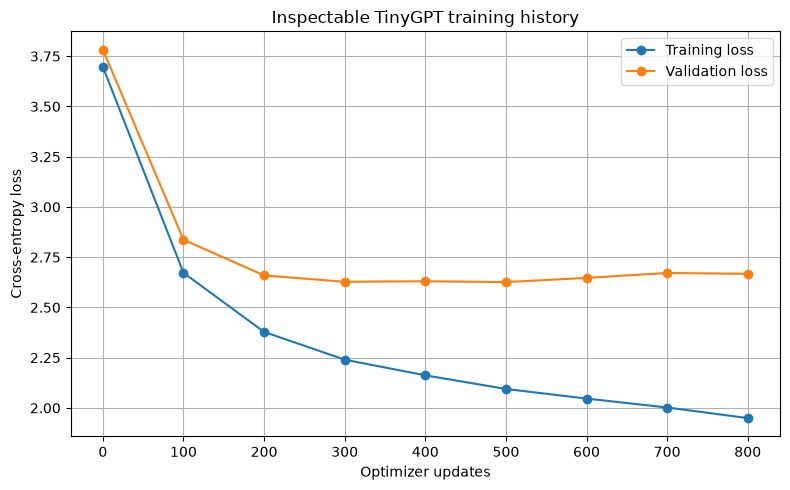

In [10]:
import matplotlib.pyplot as plt  # noqa: I001


plt.figure(figsize=(8, 5))
plt.plot(
    training_result.evaluation_steps,
    training_result.training_losses,
    marker="o",
    label="Training loss",
)
plt.plot(
    training_result.evaluation_steps,
    training_result.validation_losses,
    marker="o",
    label="Validation loss",
)
plt.xlabel("Optimizer updates")
plt.ylabel("Cross-entropy loss")
plt.title("Inspectable TinyGPT training history")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Training loss falls throughout the retained run, while validation loss improves most through roughly step `300` and then stays flat or worsens slightly.

The later gap is evidence of overfitting in this tiny setup, but it does not invalidate the structural attention checks below.

## Extract attention for one prompt

The short prompt `Alice saw` fits comfortably within the model context and keeps every heatmap label readable.

Inspection uses evaluation mode so embedding, attention, and residual-branch dropout are disabled.

In [11]:
@torch.no_grad()
def get_attention_for_prompt(
    model: InspectableTinyGPT,
    prompt: str,
) -> tuple[torch.Tensor, list[str], list[torch.Tensor]]:
    model.eval()
    prompt_ids = encode_text(prompt)
    input_ids = torch.tensor([prompt_ids], dtype=torch.long)
    logits, _, attention_by_layer = model(
        input_ids,
        return_attention_weights=True,
    )
    if attention_by_layer is None:
        raise RuntimeError("Attention weights were not returned.")
    return logits, decode_to_tokens(prompt_ids), attention_by_layer


prompt = "Alice saw"
prompt_logits, prompt_tokens, attention_by_layer = get_attention_for_prompt(
    model, prompt
)
print("Prompt:", repr(prompt))
print("Tokens:", prompt_tokens)
print("Logit shape:", tuple(prompt_logits.shape))
for layer_index, layer_weights in enumerate(attention_by_layer):
    print(f"Layer {layer_index} attention shape:", tuple(layer_weights.shape))

Prompt: 'Alice saw'
Tokens: ['A', 'l', 'i', 'c', 'e', ' ', 's', 'a', 'w']
Logit shape: (1, 9, 35)
Layer 0 attention shape: (1, 4, 9, 9)
Layer 1 attention shape: (1, 4, 9, 9)


## Verify probability and masking contracts

Each layer must expose `[1, 4, 9, 9]` for this one-item, four-head, nine-character prompt.

The checks cover every head rather than only the first displayed matrix.

In [12]:
sequence_length = len(prompt_tokens)
expected_attention_shape = (
    1,
    attention_config["number_of_attention_heads"],
    sequence_length,
    sequence_length,
)

largest_future_weight = 0.0
for layer_weights in attention_by_layer:
    if tuple(layer_weights.shape) != expected_attention_shape:
        raise RuntimeError("Unexpected attention tensor shape.")
    row_sums = layer_weights.sum(dim=-1)
    future_weights = torch.triu(layer_weights, diagonal=1)
    if not torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-6):
        raise RuntimeError("Attention rows do not sum to one.")
    if not torch.equal(future_weights, torch.zeros_like(future_weights)):
        raise RuntimeError("Causal attention assigned weight to a future position.")
    largest_future_weight = max(
        largest_future_weight,
        float(future_weights.max().item()),
    )

print("All row sums are approximately 1.")
print("Largest future-position weight:", largest_future_weight)

All row sums are approximately 1.
Largest future-position weight: 0.0


## Plot one labeled heatmap

Position prefixes distinguish repeated character tokens such as spaces and repeated letters.

The selected matrix is layer `0`, head `0`, batch item `0`.

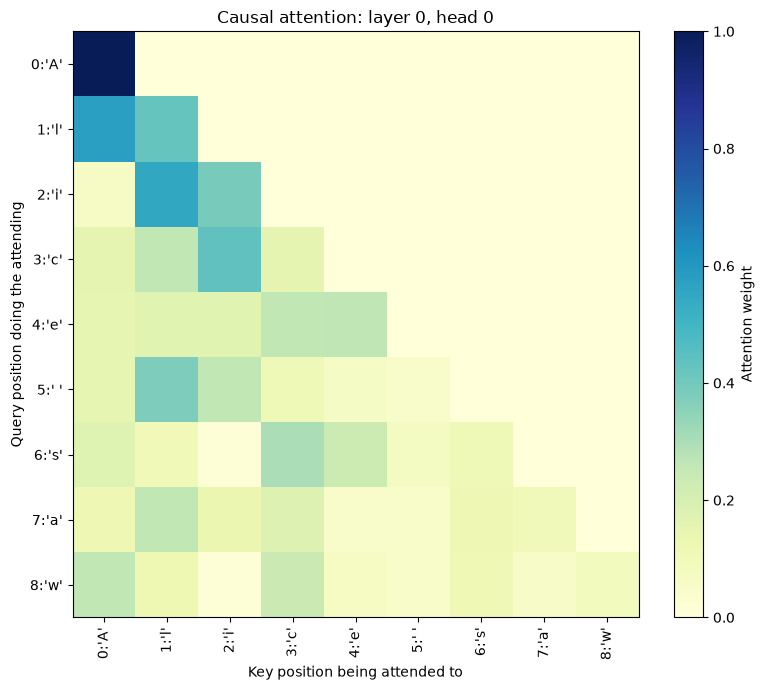

In [13]:
def make_position_labels(tokens: list[str]) -> list[str]:
    return [f"{position}:{token!r}" for position, token in enumerate(tokens)]


def plot_attention_heatmap(
    attention_matrix: torch.Tensor,
    tokens: list[str],
    title: str,
) -> None:
    if attention_matrix.ndim != 2:
        raise ValueError("attention_matrix must be two-dimensional.")
    expected_shape = (len(tokens), len(tokens))
    if tuple(attention_matrix.shape) != expected_shape:
        raise ValueError("Matrix dimensions must match the token count.")
    labels = make_position_labels(tokens)
    figure, axis = plt.subplots(figsize=(8, 7))
    image = axis.imshow(
        attention_matrix.detach().cpu().numpy(),
        vmin=0.0,
        vmax=1.0,
        cmap="YlGnBu",
        aspect="auto",
    )
    figure.colorbar(image, ax=axis, label="Attention weight")
    axis.set_xticks(range(len(labels)), labels=labels, rotation=90)
    axis.set_yticks(range(len(labels)), labels=labels)
    axis.set_xlabel("Key position being attended to")
    axis.set_ylabel("Query position doing the attending")
    axis.set_title(title)
    figure.tight_layout()
    plt.show()


selected_attention = attention_by_layer[0][0, 0]
plot_attention_heatmap(
    selected_attention,
    prompt_tokens,
    "Causal attention: layer 0, head 0",
)

The blank upper triangle is the causal mask, not evidence that the head learned to ignore future tokens.

Masking makes those positions unavailable before softmax.

## Compare every layer and head

A shared color scale makes values comparable across the eight heatmaps.

Rows of subplots correspond to Transformer layers and columns correspond to heads.

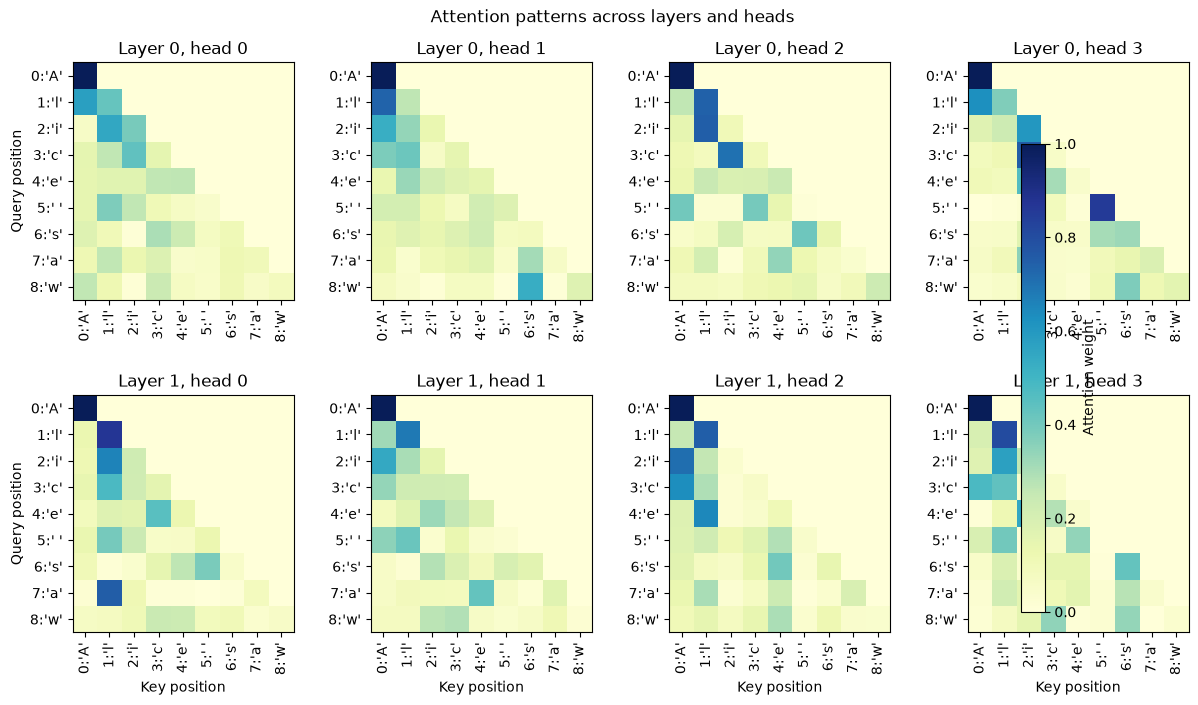

In [14]:
def plot_all_attention_heads(
    attention_by_layer: list[torch.Tensor],
    tokens: list[str],
    batch_index: int = 0,
) -> None:
    number_of_layers = len(attention_by_layer)
    number_of_heads = attention_by_layer[0].shape[1]
    labels = make_position_labels(tokens)
    figure, axes = plt.subplots(
        number_of_layers,
        number_of_heads,
        figsize=(3.6 * number_of_heads, 3.8 * number_of_layers),
        squeeze=False,
    )
    image = None
    for layer_index, layer_weights in enumerate(attention_by_layer):
        for head_index in range(number_of_heads):
            axis = axes[layer_index][head_index]
            image = axis.imshow(
                layer_weights[batch_index, head_index].detach().cpu().numpy(),
                vmin=0.0,
                vmax=1.0,
                cmap="YlGnBu",
                aspect="auto",
            )
            axis.set_title(f"Layer {layer_index}, head {head_index}")
            axis.set_xticks(range(len(labels)), labels=labels, rotation=90)
            axis.set_yticks(range(len(labels)), labels=labels)
            if layer_index == number_of_layers - 1:
                axis.set_xlabel("Key position")
            if head_index == 0:
                axis.set_ylabel("Query position")
    if image is None:
        raise RuntimeError("No attention heads were available to plot.")
    figure.colorbar(image, ax=axes, label="Attention weight", shrink=0.8)
    figure.suptitle("Attention patterns across layers and heads")
    figure.subplots_adjust(top=0.91, bottom=0.16, wspace=0.35, hspace=0.4)
    plt.show()


plot_all_attention_heads(attention_by_layer, prompt_tokens)

Different heads distribute weight differently, but a visual pattern should be described before it is assigned a function.

For example, “head 2 places more final-position weight on nearby keys” is an observation, while “head 2 understands syntax” would require additional evidence.

## Summarize final-position attention

Generation uses the final hidden position to produce next-token logits, so its attention row is a useful focused comparison.

Entropy measures how spread out that row is, while the largest-weight key identifies its strongest routed position.

Neither statistic measures causal importance to the output.

In [15]:
def attention_entropy(attention_values: torch.Tensor) -> float:
    safe_values = attention_values.clamp_min(1e-12)
    entropy = -(safe_values * safe_values.log()).sum()
    return float(entropy.item())


print("layer head | entropy | strongest key")
print("-" * 48)
for layer_index, layer_weights in enumerate(attention_by_layer):
    for head_index in range(layer_weights.shape[1]):
        final_attention = layer_weights[0, head_index, -1]
        strongest_position = int(final_attention.argmax().item())
        strongest_label = make_position_labels(prompt_tokens)[strongest_position]
        print(
            f"{layer_index:>5} {head_index:>4} | "
            f"{attention_entropy(final_attention):>7.4f} | {strongest_label}"
        )

layer head | entropy | strongest key
------------------------------------------------
    0    0 |  1.9556 | 0:'A'
    0    1 |  1.4864 | 6:'s'
    0    2 |  2.1086 | 8:'w'
    0    3 |  1.8645 | 6:'s'
    1    0 |  2.0125 | 3:'c'
    1    1 |  1.8929 | 3:'c'
    1    2 |  1.9725 | 4:'e'
    1    3 |  1.5472 | 3:'c'


In this run, layer `0` head `1` and layer `1` head `3` have the most concentrated final rows among their respective layers.

Their strongest keys differ, which documents head-to-head variation for this prompt without assigning either head a general semantic role.

## Plot final-position distributions

These bar charts remove earlier query rows and compare only the weights used in each head's final attention calculation.

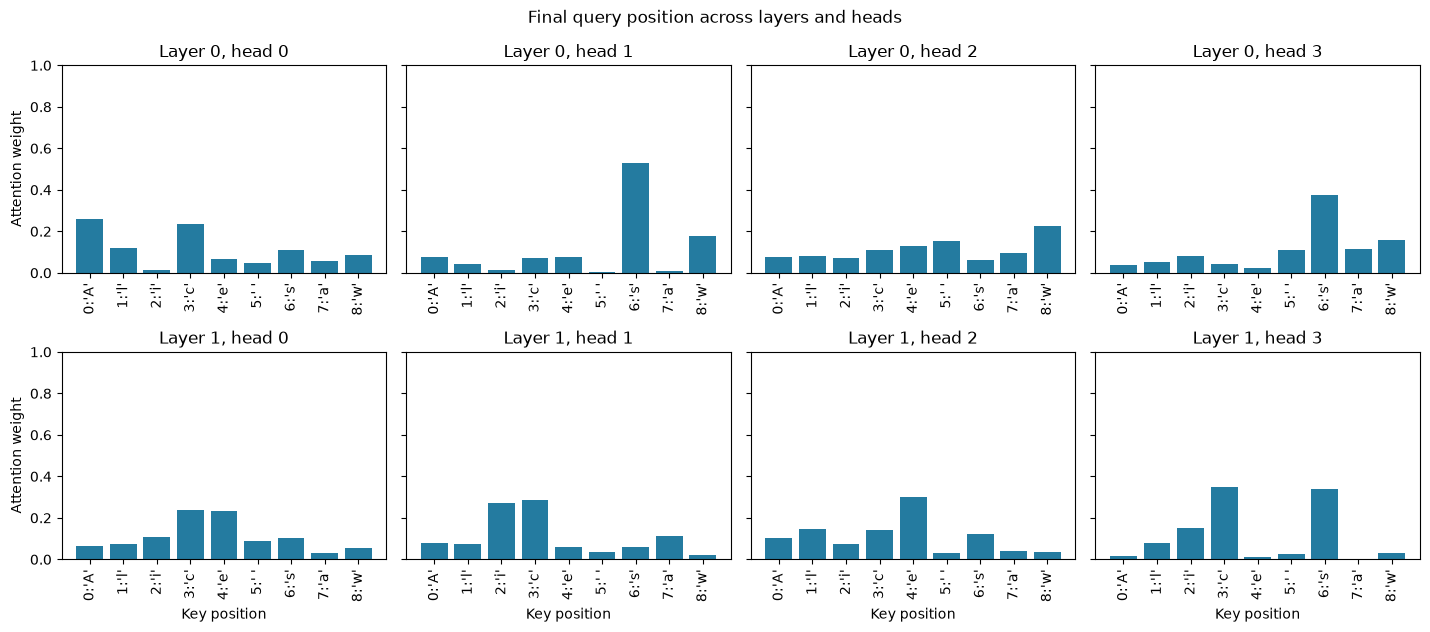

In [16]:
def plot_final_position_attention(
    attention_by_layer: list[torch.Tensor],
    tokens: list[str],
) -> None:
    number_of_layers = len(attention_by_layer)
    number_of_heads = attention_by_layer[0].shape[1]
    labels = make_position_labels(tokens)
    figure, axes = plt.subplots(
        number_of_layers,
        number_of_heads,
        figsize=(3.6 * number_of_heads, 3.2 * number_of_layers),
        sharey=True,
        squeeze=False,
    )
    for layer_index, layer_weights in enumerate(attention_by_layer):
        for head_index in range(number_of_heads):
            axis = axes[layer_index][head_index]
            values = layer_weights[0, head_index, -1].detach().cpu().tolist()
            axis.bar(range(len(tokens)), values, color="#247ba0")
            axis.set_title(f"Layer {layer_index}, head {head_index}")
            axis.set_xticks(range(len(labels)), labels=labels, rotation=90)
            axis.set_ylim(0.0, 1.0)
            if layer_index == number_of_layers - 1:
                axis.set_xlabel("Key position")
            if head_index == 0:
                axis.set_ylabel("Attention weight")
    figure.suptitle("Final query position across layers and heads")
    figure.tight_layout()
    plt.show()


plot_final_position_attention(attention_by_layer, prompt_tokens)

## Inspect the prediction beside attention

The final logits show what the whole network predicts next.

Displaying them beside attention is useful for investigation, but their coexistence does not prove that the largest attention cell caused a particular logit.

In [17]:
next_token_probabilities = torch.softmax(prompt_logits[0, -1], dim=-1)
top_probabilities, top_token_ids = torch.topk(next_token_probabilities, k=8)

print("Top next-character predictions:")
for probability, token_id in zip(
    top_probabilities.tolist(), top_token_ids.tolist(), strict=True
):
    print(f"{id_to_character[token_id]!r}: {probability:.4f}")

Top next-character predictions:
'h': 0.2582
'i': 0.2388
'a': 0.2020
'o': 0.0884
'n': 0.0618
'e': 0.0421
't': 0.0286
' ': 0.0112


## Keep inspection deterministic

Evaluation mode disables every dropout module and makes repeated inspection of the same prompt stable.

Returning pre-attention-dropout weights does not make training-mode inspection stable because embedding dropout and dropout in earlier blocks can already change the inputs used to form queries and keys.

In [18]:
repeated_logits, repeated_tokens, repeated_attention = get_attention_for_prompt(
    model, prompt
)

if repeated_logits.shape != prompt_logits.shape or repeated_tokens != prompt_tokens:
    raise RuntimeError("Repeated inspection changed prompt outputs or labels.")

for first_layer_weights, repeated_layer_weights in zip(
    attention_by_layer, repeated_attention, strict=True
):
    if not torch.equal(first_layer_weights, repeated_layer_weights):
        raise RuntimeError("Evaluation-mode attention was not deterministic.")

print("Repeated evaluation-mode attention is exactly equal:", True)

Repeated evaluation-mode attention is exactly equal: True


## Apply the method to other tokenizers

The model inspection code is tokenizer-agnostic because it receives token IDs.

A subword tokenizer would supply labels such as `['Alice', ' saw']` instead of individual characters.

The tokenizer used for labels must be the same tokenizer that produced the model's IDs.

Subword labels are often easier to read, but the meaning and limitations of the weights do not change.

## Verify the experiment contracts

The final checks protect the intended update count, checkpoint schedule, layer count, and finite stored outputs.

In [19]:
expected_steps = list(range(0, attention_config["training_steps"] + 1, 100))
assert training_result.optimizer_updates == attention_config["training_steps"]
assert training_result.evaluation_steps == expected_steps
assert len(attention_by_layer) == attention_config["number_of_transformer_blocks"]
assert all(
    math.isfinite(loss)
    for loss in training_result.training_losses + training_result.validation_losses
)
assert model.training is False
print("All training and attention-inspection contracts passed.")

All training and attention-inspection contracts passed.


## Common mistakes

- Reversing rows and columns changes “query attends to key” into the wrong statement.

- Calling the masked upper triangle learned behavior confuses an architectural constraint with a learned pattern.

- Inspecting after `model.train()` allows dropout and upstream changes to make the result stochastic.

- Returning dropped attention weights makes row sums random during training and harder to interpret.

- Labeling repeated tokens without positions makes a character heatmap ambiguous.

- Treating a visually strong weight as causal importance ignores value vectors and the rest of the network.

- Assigning a semantic role to one head from one prompt overgeneralizes from insufficient evidence.

- Plotting long prompts or every prompt produces unreadable, repetitive figures rather than insight.

## Takeaways

- Optional returns let the same attention computation support training and inspection.

- One layer's weights use `[batch, head, query, key]` layout.

- Pre-dropout attention rows sum to approximately `1`, and causal masking forces future-key weights to `0`.

- Shared-scale, position-labeled plots support direct comparison across layers and heads.

- Evaluation mode is required for stable inspection.

- Attention patterns reveal one information-routing mechanism, not a complete causal explanation of predictions.

## What comes next

Attention inspection reveals where heads route information, while activation and logit inspection can show how intermediate values and output preferences change.

Combining multiple measurements is more informative than relying on one heatmap alone.